In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [40]:
df = pd.read_csv('heart_disease_uci.csv')

In [41]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [42]:
df = df.drop(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'], axis=1)

In [43]:
df.head()

,id,age,trestbps,chol,thalch,oldpeak,num
0,1,63,145.0,233.0,150.0,2.3,0
1,2,67,160.0,286.0,108.0,1.5,2
2,3,67,120.0,229.0,129.0,2.6,1
3,4,37,130.0,250.0,187.0,3.5,0
4,5,41,130.0,204.0,172.0,1.4,0


In [44]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [45]:
missing_values = df.isnull().sum()
print(missing_values)

id           0
age          0
trestbps    59
chol        30
thalch      55
oldpeak     62
num          0
dtype: int64


In [46]:
df.shape

(920, 7)

In [47]:
df_cleaned = df.dropna()

In [48]:
df_cleaned.head()

,id,age,trestbps,chol,thalch,oldpeak,num
0,1,63,145.0,233.0,150.0,2.3,0
1,2,67,160.0,286.0,108.0,1.5,2
2,3,67,120.0,229.0,129.0,2.6,1
3,4,37,130.0,250.0,187.0,3.5,0
4,5,41,130.0,204.0,172.0,1.4,0


In [49]:
df_cleaned.shape

(827, 7)

In [50]:
import seaborn as sns

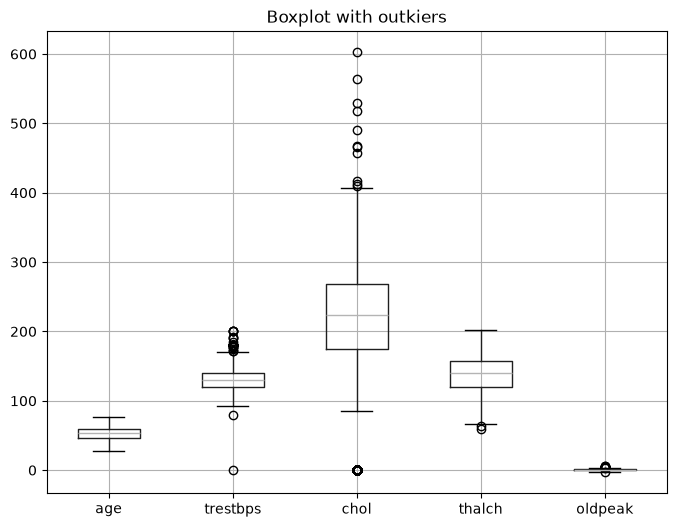

In [51]:
plt.figure(figsize=(8,6))
df.boxplot(column=['age', 'trestbps', 'chol', 'thalch', 'oldpeak'])
plt.title('Boxplot with outkiers')
plt.show()

In [52]:
def remove_outliers(df, columns=None):
    clean_df = df.copy()
    
    for col in columns: 
        Q1 = clean_df[col].quantile(0.25)
        Q3 = clean_df[col].quantile(0.75)
        
        IQR = Q3-Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        clean_df = clean_df[(clean_df[col] >= lower_bound) & (clean_df[col] <= upper_bound)]
        
        return clean_df

In [53]:
columns = [ 'trestbps', 'chol', 'thalch', 'oldpeak']

df_cleaned = remove_outliers(df_cleaned, columns)

In [54]:
df_cleaned.head()

,id,age,trestbps,chol,thalch,oldpeak,num
0,1,63,145.0,233.0,150.0,2.3,0
1,2,67,160.0,286.0,108.0,1.5,2
2,3,67,120.0,229.0,129.0,2.6,1
3,4,37,130.0,250.0,187.0,3.5,0
4,5,41,130.0,204.0,172.0,1.4,0


In [55]:
df_cleaned.shape

(800, 7)

In [56]:
df_cleaned.describe()

,id,age,trestbps,chol,thalch,oldpeak,num
count,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,429.79625,53.057500,130.708750,201.186250,137.960000,0.872750,0.961250
std,257.33297,9.415014,16.187077,109.259375,25.754077,1.088802,1.115259
min,1.00000,28.000000,92.000000,0.000000,60.000000,-2.600000,0.000000
25%,207.75000,46.000000,120.000000,178.750000,120.000000,0.000000,0.000000
50%,425.50000,54.000000,130.000000,224.000000,140.000000,0.500000,1.000000
75%,643.25000,60.000000,140.000000,267.000000,158.000000,1.500000,2.000000
max,920.00000,77.000000,170.000000,603.000000,202.000000,6.200000,4.000000


In [57]:
x = df_cleaned.drop('num', axis=1)
y = df_cleaned['num']

In [58]:
feature_columns = x.columns.to_list()

In [59]:
feature_columns

['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak']

In [60]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state=42)

In [61]:
# from sklearn.preprocessing import StandardScaler

In [62]:
# scaler = StandardScaler()
# x_train_scaled = scaler.fit_transform(x_train)
# x_test_scaled = scaler.fit_transform(x_test)

In [63]:
# model = RandomForestClassifier()
# model.fit(x_train, y_train)

In [64]:
# y_pred = model.predict(x_test_scaled)
# cm = confusion_matrix(y_test, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm)
# disp.plot()
# plt.title("confusion_matrix")
# plt.show()
# print("Classification Report")
# print(classification_report(y_test, y_pred))

In [65]:
model = RandomForestClassifier()

In [66]:
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [67]:
y_pred = model.predict(x_test)

In [68]:
cm = confusion_matrix(y_test, y_pred)

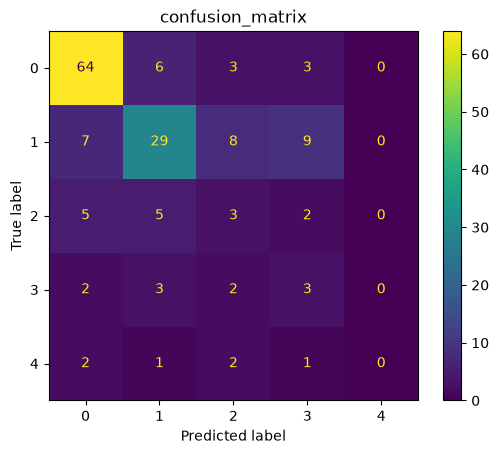

In [69]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("confusion_matrix")
plt.show()

In [70]:
df_cleaned['num'].value_counts()

num
0    362
1    235
2     98
3     82
4     23
Name: count, dtype: int64

In [71]:
print("Classification Report")
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        76
           1       0.66      0.55      0.60        53
           2       0.17      0.20      0.18        15
           3       0.17      0.30      0.21        10
           4       0.00      0.00      0.00         6

    accuracy                           0.62       160
   macro avg       0.36      0.38      0.36       160
weighted avg       0.62      0.62      0.62       160



c:\Users\Shuvo Majumder\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shuvo Majumder\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shuvo Majumder\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

In [73]:
# Infrance code
def predict_heart_disease(input_data: dict):
    input_df = pd.DataFrame([input_data])
    input_df = input_df[feature_columns]
    
    prediction = model.predict(input_df)[0]
    predict_proba = model.predict_proba(input_df)[0]
    
    print("Prediction Category: ", prediction)
    print("Prediction confidence: ", predict_proba)
    

In [78]:
sample_input = {
    'id': 7,
    'age': 62,
    'sex': 'Male',
    'cp': 'asymtomatic',
    'trestbps': 140,
    'chol': 268,
    'fbs': 'False',
    'restecg': 'lv hypertrophy',
    'thalch': 160,
    'exang':'True',
    'oldpeak': 3.6,
    'slope': 'flat',
    'ca': 2,
    'thal': 'normal'
}

predict_heart_disease(sample_input)

Prediction Category:  3
Prediction confidence:  [0.03 0.06 0.1  0.78 0.03]
